# **<span style="color: #000000;background-color: rgb(255, 245, 177)">언어모델 사전과제</span>**

### **필수내용**
- NLP
- 통계기반 모델
    - SLM
        - SLM에 사용되는 분포 가설
    - N-gram
        - N-gram이 나온 배경과 한계
    - PPL
    - NLM
        - SLM과의 차이
- 딥러닝기반 모델
    - BERT
    - GPT
    - LLM
    - RAG
        - RAG의 구조
    - Langchain
        - Langchain의 아이디어, 특징
- sLM
    - 모델 압축
    - sLM의 장단점
    - sLM과 LLM의 결합

---

### <span style="color: #000000;background-color: #ffdba4">**1. NLP와 언어 모델**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(1) NLP(Natural Language Processing)**</span> 
<U>**인간의 언어(자연어)의 의미를 분석하고, 컴퓨터가 처리할 수 있도록 하는 인공지능 기술 분야**</U>
- 역할 : 모호한 자연어를 컴퓨터가 이해할 수 있는 숫자로 변환하여 유의미한 가치 창출

##### **[자연어 <-> 프로그래밍 언어]**
- 프로그래밍 언어 : 엄격한 규칙, 논리적, 일대일 대응. 에러나면 돌아가지 않음
- 자연어 : 인간이 소통을 위해 자연발생적으로 사용하는 언어. 일대다 대응

##### **[자연어의 특징]**
1. 이산적 데이터(Discreteness)
    - 특징 : 언어는 '단위'라는 독립적이고 딱 끊어지는 단위로 구성됨
    - NLP의 숙제 : 컴퓨터가 이해할 수 있도록 이산적인 단어를 연속적인 벡터로 변환하는 과정(Embedding)이 반드시 필요
2. 순차적 데이터(Sequentiality)
    - 특징 : 단어가 나열되는 순서에 따라 문장의 의미가 완전히 결정됨
    - NLP의 숙제 : 데이터의 앞뒤 관계와 위치 정보를 유지하며 처리할 수 있는 모델 구조가 필요
3. 중의성과 모호성(Ambiguity)
    - 특징 : 동일한 형태의 단어라도 문맥에 따라 뜻이 천처만별 (예시 : 배(과일/탈것/신체부위))
    - NLP의 숙제 : 단어 하나가 아닌 문맥을 전체적으로 파악해야 함
4. 희소성 (Sparsity)
    - 특징 : 단어의 조합은 무한에 가깝지만, 우리가 가진 데이터가 나타나는 조합은 극히 일부(Zipf의 법칙)
    - NLP의 숙제 : 한번도 본 적 없는 문장이 들어와도 단어 간 유사도를 이용해 확률적으로 추론할 수 있는 일반화 능력이 중요함
5. 가변성과 진화 (Variability & Evolution)
    - 특징 : 언어는 고정 X, 빠르게 바뀌며 문법 파괴도 잦음
    - NLP의 숙제 : 고정된 규칙이 아니라 데이터로부터 유연하게 패턴을 학습한느 머신러닝 방식 필수

#### <span style="color: #000000;background-color: #ffc2e5">   **1-(2) 언어모델**</span> 
- 가장 넓은 의미 : 인간이 말하고 쓰는 방식을 모방하는 시스템
- 단어 시퀀스에 확률 할당 -> 가장 자연스러운 단어 시퀀스를 찾아내는 모델
    - 이전 단어들이 주어졌을때 다음 단어를 예측하도록 훈련시킴
- 구분 : 통계 기반 vs 인공 신경망 기반

### <span style="color: #000000;background-color: #ffdba4">**2. 통계적 언어 모델 (SLM)**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(1) Statistic Language Model이란?**</span> 

<U>**분포 가설이라는 아주 중요한 아이디어에 근거**</U>  
- 분포가설?
    - *비슷한 문맥에서 함께 나타나는 단어들은 비슷한 의미를 가진다*는 가설
    - 기본 개념 : 조건부 확률 & 카운트기반 확률
- 조건부 확률
    - 확률 활용 방식
    - 예시) '나는 버스를'까지만 있는 상황에서는 다음에 '탔다'가 올 확률이 높음 -> 선택
- 카운트 기반
    - 이전 단어 시퀀스의 등장 빈도를 통해 다음 단어의 확률 계산
    - 한계 : **희소 문제** => 새로운 문장 조합에 약함

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(2) N-gram**</span> 
- N-gram이 나오게 된 배경
    - SLM은 희소하게 등장한 것에 대해서는 잘 예측을 못하고, 문장이 길어질수록 다음 단어를 계산하기 어려움  
    => 전체 문장 대신 문장 일부만 보면 어떰? = N-gram
- 한계
    - 희소문제 
        - 데이터 부족 : 훈련 데이터에서 나타나지 않은 단어 조합은 확률이 0이 됨 -> 해당 단어 시퀀스를 예측하거나 평가할 수 없음
        - N의 크기가 커질수록 훈련 데이터에서 해당 조합을 찾기 어려워짐 -> 희소문제 심각
    - 문맥 제한
        - 앞선 N-1개의 단어만 고려 -> 문장 앞부분에 나온 정보를 뒷부분 결정에 반영 못함

#### <span style="color: #000000;background-color: #ffc2e5">   **2-(3) Perplexity(PPL)**</span> 
- PPL : 언어 모델이 문장을 얼마나 '혼란스러워하는지'를 수치로 나타낸 것
    - 문장이 희소하게 등장할수록 PPL 증가(훈련 데이터에서 더 적게 봤으니까)
    - 단어 개수가 커질수록 PPL 감소(함께 보는 단어가 많아지니까)
    - PPL이 낮다=혼란이 덜하다=모델이 문맥을 잘 이해한다=모델의 성능이 좋다
- 신경망 기반 언어 모델은 단어와 문맥 간의 관계를 학습하여 일반화하는 능력이 뛰어남  
    => 훈련데이터에서 직접 보지 못한 문장이더라도 훨씬 유연하게 대처 가능

### <span style="color: #000000;background-color: #ffdba4">**3. 신경망 언어 모델(NLM)**</span>
키워드 : **"임베딩"** (토큰이 벡터로 변환) 

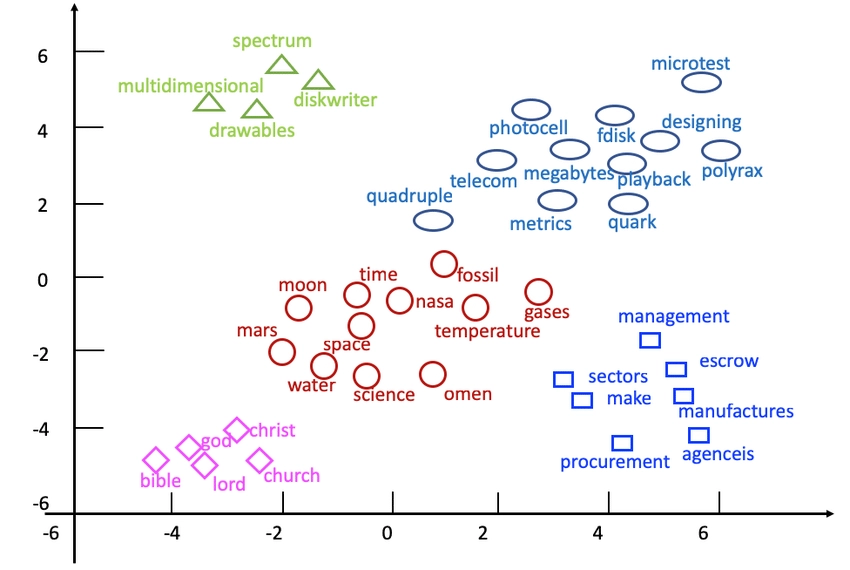

- SLM이 단어를 단순히 '이름'으로만 기억했다면, NLM은 모든 단어를 거대한 다차원 지도 위의 한 점으로 보냄(=워드 임베딩)
##### [예시] 축구와 농구
- 통계 모델 : 훈련 데이터에 '재밌는 축구를 한다'라는 문장이 없으면 확률을 0으로 처리
- NLM
    1. 학습 데이터에서 '재밌는 농구를 한다'를 학습
    2. 축구와 농구가 유사한 벡터임을 인지
    3. '재밌는 축구를 한다'라는 문장을 처음 봐도 높은 확률 부여
- 신경망 언어 모델은 단어를 기호에서 벡터로 바꿈(임베딩) => 데이터에 없는 문맥도 어느 정도 예측할 수 있는 **일반화 능력**을 얻게 됨

| **특징** | **통계적 모델 (N-gram)** | **신경망 모델 (NNLM)** |
| --- | --- | --- |
| **미학습 단어 조합** | 확률 0 (예측 불가) | 유사 단어를 통해 확률 추론 가능 |
| **저장 공간** | 데이터가 늘수록 기하급수적 증가 | 가중치(Weight)만 저장하면 됨 |
| **의미 파악** | 불가능 (단순 빈도수) | 가능 (임베딩 벡터 간 거리 계산) |

### <span style="color: #000000;background-color: #ffdba4">**4. 딥러닝 기반 모델**</span>

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(1) Transformer의 등장**</span> 
##### [Transformer의 구조]
- 인코더와 디코더가 여러 layer로 구성  
    => 신경망을 깊게 쌓으면서 언어 모델의 표현력이 높아져 현재의 딥러닝 기반 언어모델이 가능해짐

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(2) BERT**</span> 
##### **[정의]**
<U>**BERT = Bidirectional Encoder Representations from Transformers**</U>

- Bidirectional : 텍스트의 앞뒤 문맥을 동시에 고려(양방향으로 작동)
- Encoder : 입력값 -> 벡터
- Transformers : 딥러닝 모델
- 특징
    - 양방향 : 문장을 읽을 때 앞뒤를 동시에 고려  
        - 한 단어를 이해할 때 그 단어의 좌우 문맥을 동시에 보고 이해
    - 트랜스포머 기반 : 트랜스포머 구조의 encoder 부분만 사용
    - 사전 학습 + 파인튜닝 : 큰 데이터로 먼저 일반적인 언어 능력 학습-> 나중에 특정 과제에 맞게 조정

##### **[학습 방법]**
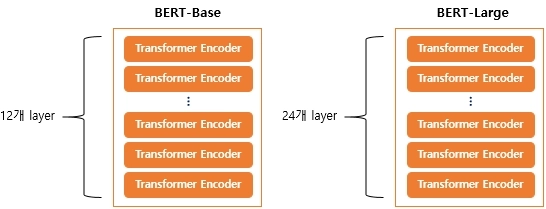  
- 처리 과정
    - input -> embedding -> 트랜스포머 인코더 12개(or 24개) -> output
    - BERT는 입력 문장을 임베딩한 뒤 여러개의 인코더를 통과하면서 각 단어의 의미를 문맥적으로 풍부하게 만듦
    - 트랜스포머는 디코더까지 있음 => 문장 생성 목적
    - BERT는 인코더만 있음 => 문장 이해 목적
- 사전 학습
    - Masked Language Model(MLM)
        - 빈칸 채우기 방식으로 학습
        - 'I go to school'이라는 문장이 있으면, 이 중에 무작위로 go를 빈칸으로 뚫어서 I __ to school이라고 만들고 빈칸에 어떤 단어가 들어갈지 모델이 예측하면서 학습  
        -> 자연스럽게 문맥을 이해하고 추론하는 능력 향상
    - Next Sentence Prediction(NSP)
        - 두 문장에 대해 이 문장들이 서로 앞뒤 관계인지 아니면 그냥 무작위 위치에 있는 두개의 문장인지를 학습  
        -> 두 문장이 이어지는 논리 흐름 학습

##### **[이후 모델]**
- RoBERTa: BERT의 사전 훈련 프로세스를 개선하여 성능을 향상시킨 모델
    - 주요 차이점
        - 더 거대한 데이터셋, 더 긴 학습 시간
        - NSO 제거(성능 이슈)
        - 배치 크기 및 학습률 최적화
        - 마스킹 패턴을 동적으로 변경해 다양한 패턴 학습
- ALBERT(A lite BERT) : BERT의 경량화 버전
    - 주요 차이점
        - 파라미터 공유 : 레이어간 파라미터 공유 => 모델 크기 감소
        - 임베딩 행렬 분해 : 임베딩 행렬을 두 개의 더 작은 행렬로 분해 => 계산 비용과 메모리 요구량을 크게 줄임

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(3) GPT**</span> 
##### **[정의]**
- 트랜스포머의 디코더 기반
    - 트랜스포머의 디코더는 미래의 단어를 볼 수 없음(masking)  
    = GPT도 지금까지의 단어를 바탕으로 다음 단어 예측
- GPT 3부터 few-shot learning 도입
    - 몇개의 예시를 보고 태스크를 수행

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(4) LLM**</span> 
##### **[정의]**
- Large Language Model = 거대 언어 모델
- 방대한 양의 데이터를 학습하여 자연어 및 기타 유형의 콘텐츠를 이해하고 생성하여 광범위한 작업을 수행할 수 있는 기초 모델의 범주
- 특징
    - scaling law
    - 창발적 능력 : 배운적 없는 일 수행
    - RLHF : 단순히 지식만 많은 게 아니라 사람의 의도를 이해하게 만드는 핵심 기술
    - 패러다임의 전환 : 튜닝->프롬프트

##### **[작동 방식]**
1. 대규모 학습(Training)
    - 수십억개의 문장으로 이루어진 방대한 데이터 학습
    - 이 과정에서 언어의 패턴을 스스로 터득
2. 예측 및 생성(Prediction & Generation)
    - 학습이 완료된 LLM은 프롬프트를 받으면 학습한 패턴을 기반으로 다음에 올 가장 확률 높은 단어를 순서대로 예측하며 응답 생성
- LLM은 텍스트를 생성하는 것을 궁극적인 목표로 하기 때문에 GPT 방식 사용

##### **[LLM의 한계]**
- hallucination - 환각처럼 그럴 듯하지만 틀린 정보를 말하는것(지금은 해결)
- 업데이트 비용 - 파라미터 수가 엄청나게 많기 때문에 새로운 정보를 반영할때 계산량이 매우 많음

#### <span style="color: #000000;background-color: #ffc2e5">   **4-(5) RAG**</span> 
##### **[RAG의 필요성]**
- LLM은 학습할 당시의 지식만 갖고 있고, 그 이후에 새롭게 나타난 지식에 대해서는 답변 할 수 없음  
=> 외부에서 최신 정보를 가져와서 답변하게 하기 위한 것이 **RAG**!
- <U>*질문에 대해 모델이 모르면 검색해서 답하는 구조*</U>

##### **[RAG의 구조]**
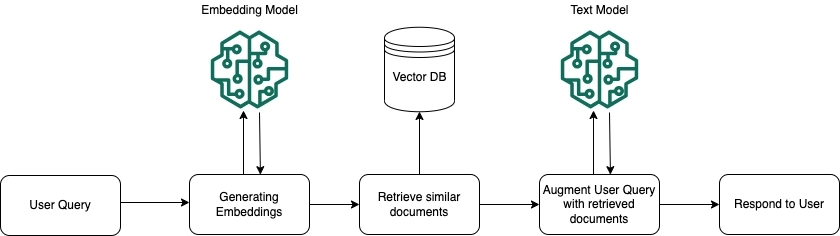
- 질의 인코더 : 사용자의 질문을 벡터로 바꿈
- 지식 검색기 : 인코딩된 질문을 바탕으로 외부 지식에서 관련 내용 검색
- 지식 증강 생성기 : 검색한 내용을 참고해서 답변 생성

##### **[RAG의 장점]**
- **최신 정보 반영 가능**
- hallucination 문제 감소(모르면 검색함)  
-> 정보 정확성도 증가

##### **[CAG(Credibility-Aware Generation)]**
- RAG의 한계를 보완하기 위해 제안된 프레임 워크
- 기존 RAG
    - 외부 문서를 검색해 모델에 제공
    - but 검색된 문서 중 일부가 신뢰성이 낮거나 잘못된 정보일 경우 생성된 답변의 품질과 정확도가 크게 하락
=> CAG : 잘못된 컨텍스트가 모델 성능에 미치는 부정적 영향 최소화, 모델이 문서를 단순히 활용하는 수준을 넘어 문서의 신뢰도를 판단하고 활용할 수 있도록 훈련시키는 기법
- 구조
    - 질문 입력 -> 정보 검색 -> 각 정보의 신뢰도 평가 -> 높은 신뢰도 정보 우선 사용 -> 최종 답변 생성


#### <span style="color: #000000;background-color: #ffc2e5">   **4-(6) LangChain**</span> 
##### **[LangChain]**
- 정의
    - LLM+RAG 파이프라인을 쉽게 구성할 수 있도록 도와주는 역할 = LangChain 프레임워크
    - LLM을 기반으로 앱 제작 시 필요한 구성 요소 쉽게 연결
    - 파이썬과 자바스크립트 라이브러리 제공 -> 다양하게 활용 가능
- 특징
    - 추상화 : LLM 서비스를 만들 때 필요한 각종 작업을 간결하게 표현
    - 표준화 : 비슷한 기능을 갖추고 있는 요소들을 똑같은 형식을 갖춘 컴포넌트로 표준화
    - 체이닝 : 자주 활용하는 주요 컴포넌트를 쉽게 연결해서 LLM 서비스으 ㅣ로직을 쉽게

##### **[LangGraph]**
- LangChain의 한계
    - 선형적인 체인 구조 -> 이전 단계로 돌아가 다시 실행하는 등 복잡한 로직 구현하기 어려움  
=> **LangGraph 등장**
- 비선형적인 작업 형태(Cycle, Loop)
- 노드 : 특정 작업을 수행하는 단위, '무엇을 할 것인가'
- 엣지 : 노드와 노드를 연결하는 선, '다음에 어디로 갈 것인가'

##### **[LangSmith]**
- LangChain 프레임워크를 만든 팀에서 개발한 LLM 기반 어플리케이션을 위한 통합 개발 및 운영 플랫폼
- 핵심 기능
    - 디버깅 및 추적 : 앱의 모든 실행과정을 단계별로 시각화
    - 테스트 및 평가 : 미리 질문과 정답 데이터셋을 만들어 개발 중인 앱의 성능을 자동으로 평가
    - 모니터링 : 실제 사용자들이 앱을 어떻게 사용하는지 모니터링
    - 프롬프트 허브 : 다양한 프롬프트를 저장하고 버전 관리 -> 쉽게 테스트할 수 있는 공간 제공

##### **[외부 API 활용하기]**
- LLM 내부 지식만을 이용해서 해결할 수 없는 질문에 대해서는 외부 API와 연동해서 답변 가능

### <span style="color: #000000;background-color: #ffdba4">**5. sLM (small Language Model)**</span>
##### **[sLM이란?]**
- **소규모 언어 모델** : 자연어 컨텐츠 처리, 이해 및 생성할 수 있는 AI모델
- LLM(수천억~수조 개의 매개변수)보다 규모와 범위가 작음(수백만~수십억 개 매개변수)  
-> 메모리와 연산 자원을 적게 사용   
-> 모바일 앱처럼 오프라인 추론을 통해 응답을 생성해야 하는 상황에 적합

##### **[모델 압축]**
1. 가지치기
- 신경망에서 중요도가 더 낮거나 중복되거나 불필요한 매개변수 제거
- 가지치기 되는 매개변수 : 숫자 가중치, 뉴련 자체 또는 신경망의 계층이 포함  

2. 양자화
- 고정밀 데이터를 저정밀 데이터로 변환
- 계산 부하를 줄이고 추론 속도를 높임

3. 저차원 분해
- 큰 가중치 행렬을 더 작은 저차원 행렬로 분해
- 복잡한 행렬 연산을 단순화

4. 지식 증류
- 사전 학습된 '교사모델'의 학습 내용을 '학생 모델'로 이전하는 것
- 학생모델은 교사모델의 예측과 일치시키고 기본 추론 과정을 모방하도록 학습
- 큰 모델의 지식이 더 작은 모델로 '증류'됨

##### **[sLM의 예]**  
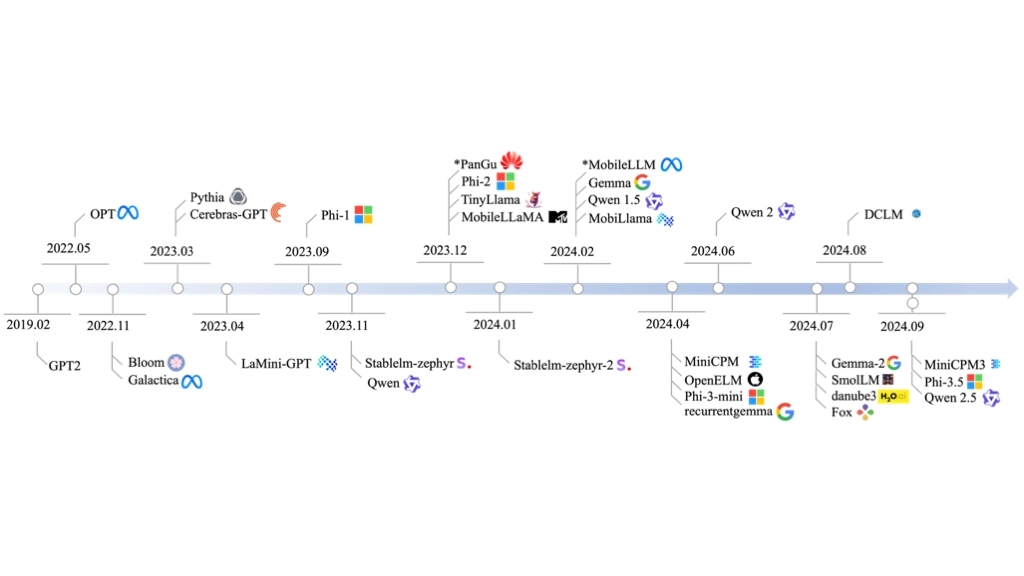  
- DistilBERT, Gemma, GPT-4o mini, Llama, Ministral, Phi 등

##### **[sLM의 장점]**
- 성능적 측면
    - 효과적인 성능 : 작은 모델에 파인튜닝 -> 필요한 기능만 빠르고 안정적으로 수행 가능
    - 지연 시간 감소 : 크기가 작아서 계산량도 적음
    - 보안 : 기업 내부 서버나 개인 기기에서 직접 실행하기가 쉬움 = 민감한 데이터를 외부 API로 보내지 않아도 됨
- 비용적 측면
    - 접근성 : 고성능 GPU없어도 사용 가능
    - 효율성 : 같은 작업을 처리해도 더 적은 자원 사용
    - 에너지 효율 : 전력 소비도 적음
    - 비용 절감 : 각종 비용 감소

##### **[sLM의 한계]**
- 편향 : 더 큰 모델에 존재하는 편향까지 함께 전달 가능 -> 성능저하
- 제한된 일반화 & 복잡한 작업에서의 성능 저하 : 특정 작업에 대해 미세 조정 -> 포괄적인 지식이 필요한 작업에 취약
- hallunation : 정보가 적고 추론 능력이 낮음

##### **[LLM과 sLM의 결합(결합추론)]**
- 복잡하고 어려운 작업 => LLM
- 가볍고 간단한 작업 => sLM  
-> LLM 수준의 높은 정확도 + LLM 토큰 사용량 최대 90% 절약